In [1]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  GEN_STRUCT — PRESENTATION (updated: Gini removed, equal weights)         ║
# ║  Hybrid Generalization Framework for Process Mining                      ║
# ╚══════════════════════════════════════════════════════════════════════════╝
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    'figure.autolayout': True, 'axes.titlesize': 13, 'axes.labelsize': 11,
    'font.size': 11, 'figure.dpi': 120
})

# ── Load benchmark data ──
df = pd.read_csv("master_benchmark_results.csv")

# Focus on 4 key miners for presentation
TARGET_MINERS = ['02_Alpha Miner', '04_Heuristics (Default)', '06_Inductive (Strict)', '09_Flower Model (Max)']
MINER_NAMES = {
    '02_Alpha Miner': 'Alpha Miner',
    '04_Heuristics (Default)': 'Heuristic Miner',
    '06_Inductive (Strict)': 'Inductive Miner',
    '09_Flower Model (Max)': 'Flower Model',
}
df = df[df['Miner'].isin(TARGET_MINERS)].copy()

VERSIONS = ['v1', 'v2_N=3', 'v2_N=6', 'v2.1_N=3', 'v2.1_N=6', 'v2.2_N=3', 'v2.2_N=6']
VERSIONS_N6 = ['v1', 'v2_N=6', 'v2.1_N=6', 'v2.2_N=6']
for v in VERSIONS:
    df[f'{v}_Gen_Total'] = 0.5 * df[f'{v}_Gen_Shadow'] + 0.5 * df[f'{v}_Gen_Struct']

# ── Gen_Struct dimensions (Gini removed — log-level metric, not model-level) ──
DIMS = ['arc_flow_score', 'reach_score', 'cyclo_score']
DIM_LABELS = ['ArcFlow', 'Reach', 'Cyclo']
CURRENT_W = [1/3, 1/3, 1/3]  # equal weights

N = '6'
dim_cols = [f'v2.2_N={N}_Struct_{d}' for d in DIMS]
miner_short = lambda m: MINER_NAMES.get(m, m.split('_', 1)[1] if '_' in m else m)

print(f"Loaded: {len(df)} rows, {df['Dataset'].nunique()} datasets, {df['Miner'].nunique()} miners")
df_2017 = df[df['Dataset'] == 'BPI_2017']  # Slides 0-6 use BPI 2017 only

dim_df = df_2017.groupby('Miner')[dim_cols].mean()
eval_df = df_2017[['Dataset', 'Miner'] + dim_cols].copy()

Loaded: 20 rows, 5 datasets, 4 miners


## Slide 0: Motivation — PM4Py Baseline vs Structural Generalization
**PM4Py's generalization metric gives near-perfect scores (~0.91) to ALL miners — it cannot tell good from bad.**

Our benchmark reveals: PM4Py scores are compressed into a narrow band, while Gen_Struct spreads scores apart, revealing true structural quality differences across miners and datasets.

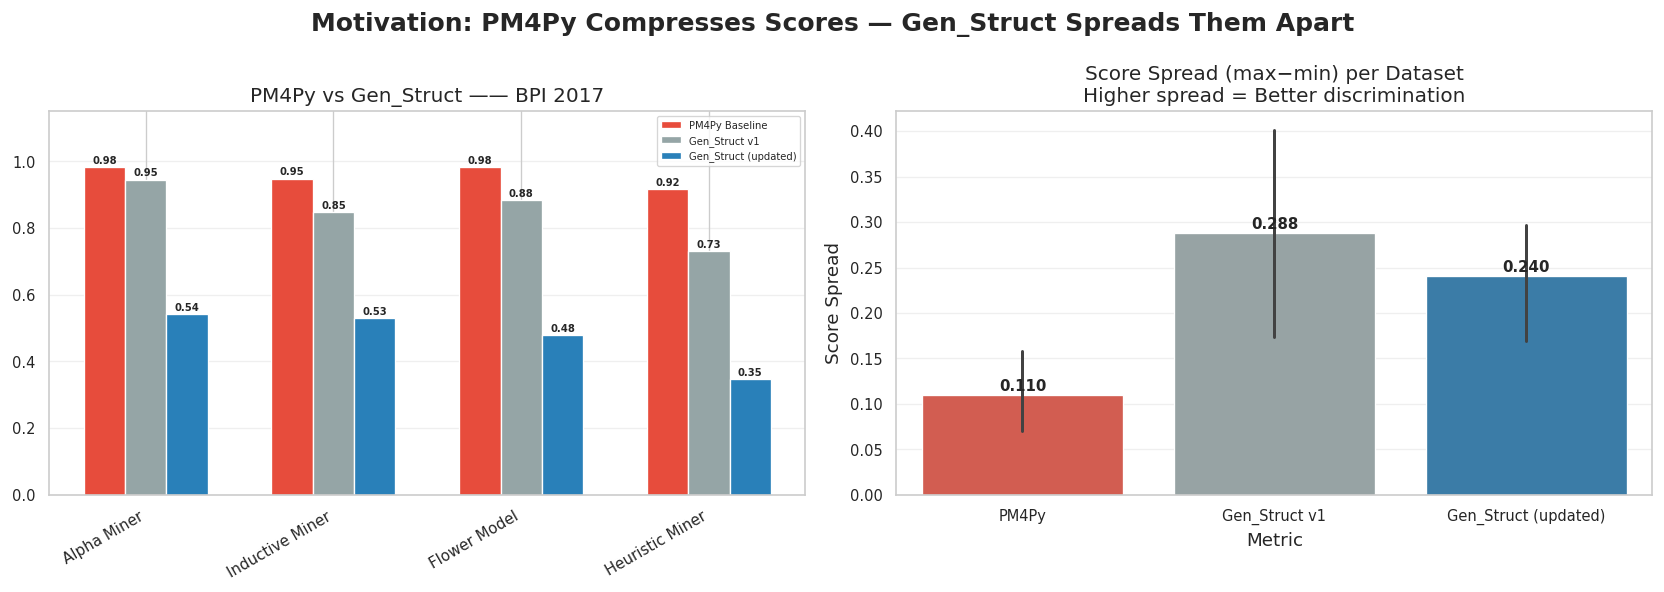

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PM4Py Baseline vs Gen_Struct v1 vs v2 — BPI 2017 only
pm4py_vs_all = df_2017.groupby('Miner')[['PM4Py_Baseline_Gen', 'v1_Gen_Struct', 'v2.2_N=6_Gen_Struct']].mean()
pm4py_vs_all.index = [miner_short(m) for m in pm4py_vs_all.index]
pm4py_vs_all = pm4py_vs_all.sort_values('v2.2_N=6_Gen_Struct', ascending=False)

x = np.arange(len(pm4py_vs_all)); w = 0.22
axes[0].bar(x - w, pm4py_vs_all['PM4Py_Baseline_Gen'], w, label='PM4Py Baseline', color='#E74C3C', edgecolor='white')
axes[0].bar(x, pm4py_vs_all['v1_Gen_Struct'], w, label='Gen_Struct v1', color='#95A5A6', edgecolor='white')
axes[0].bar(x + w, pm4py_vs_all['v2.2_N=6_Gen_Struct'], w, label='Gen_Struct (updated)', color='#2980B9', edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(pm4py_vs_all.index, rotation=30, ha='right', fontsize=9)
axes[0].set_ylim(0, 1.15); axes[0].set_title('PM4Py vs Gen_Struct —— BPI 2017', fontsize=12)
axes[0].legend(fontsize=6)
for bar in axes[0].patches:
    axes[0].annotate(f'{bar.get_height():.2f}', (bar.get_x()+bar.get_width()/2., bar.get_height()+0.01),
                     ha='center', fontsize=6, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Right: Score spread comparison — PM4Py vs Gen_Struct v1 vs v2
spread_data = []
for ds in df['Dataset'].unique():
    d = df[df['Dataset'] == ds]
    for col in ['PM4Py_Baseline_Gen', 'v1_Gen_Struct', 'v2.2_N=6_Gen_Struct']:
        s = d[col].max() - d[col].min()
        lbl = 'PM4Py' if 'PM4Py' in col else 'Gen_Struct v1' if 'v1_' in col else 'Gen_Struct (updated)'
        spread_data.append({'Dataset': ds, 'Metric': lbl, 'Spread': s})
df_spread = pd.DataFrame(spread_data)
sns.barplot(data=df_spread, x='Metric', y='Spread', hue='Metric', palette=['#E74C3C', '#95A5A6', '#2980B9'], legend=False, ax=axes[1])
axes[1].set_title('Score Spread (max−min) per Dataset\nHigher spread = Better discrimination', fontsize=12)
axes[1].set_ylabel('Score Spread')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.3f}', (p.get_x()+p.get_width()/2., p.get_height()+0.005),
                     ha='center', fontsize=9, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')



fig.suptitle('Motivation: PM4Py Compresses Scores — Gen_Struct Spreads Them Apart', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

- **Left**: v1 ranks Flower (0.968) > Alpha (0.945) — gives highest score to the trivial model; v2's Reach=0 corrects Flower to #3 (0.478), but Alpha still leads (0.543) — ranking improvement is limited to Flower  
- **Right**: v1 has high but unstable spread (large CI) — its "discrimination" is an artifact of mis-ranking Alpha high; v2 has consistent spread across datasets



## Slide 1: Gen_Struct v1 — Arc Flow Density
**Definition**: Token-replay the original log. An arc used by <1% of traces is "bloated."  
$$\text{Gen\_Struct}_{v1} = 1 - \frac{\text{bloated\_arcs}}{\text{total\_arcs}}$$

| Miner | Total Arcs | Rare Arcs | Rare Arc % | Gen_Struct |
|---|---|---|---|---|
| Flower Model | 215 | 0 | 0.0% | **0.968** |
| Alpha Miner | 55 | 3 | 5.5% | 0.945 |
| Inductive Miner | 184 | 28 | 15.2% | 0.848 |
| Heuristics Miner | 183 | 46 | 25.1% | 0.749 |

⚠ Alpha & Flower score **highest** — both exploit structural simplicity (few arcs / all arcs reachable). This is a **false positive** for Alpha.

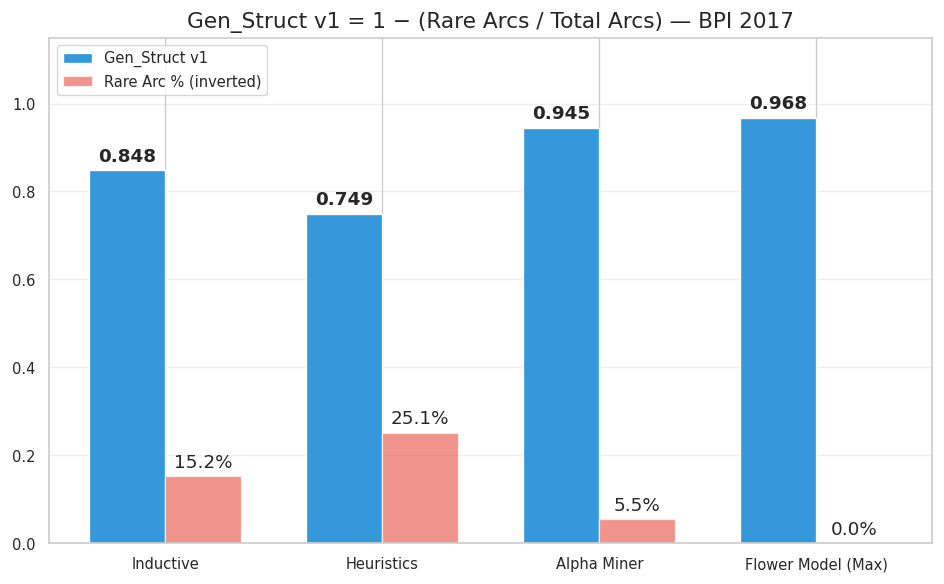

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
# BPI 2017 v1 Gen_Struct
df_2017 = df[df['Dataset'] == 'BPI_2017']
v1_data = pd.DataFrame({
    'Miner': ['Inductive (Strict)', 'Heuristics (Default)', 'Alpha Miner', 'Flower Model (Max)'],
    'v1_Gen_Struct': [0.848, 0.749, 0.945, 0.968],
    'Rare Arc %': [15.2, 25.1, 5.5, 0.0]
})

x = np.arange(len(v1_data)); w = 0.35
bars1 = ax.bar(x - w/2, v1_data['v1_Gen_Struct'], w, label='Gen_Struct v1', color='#3498DB')
bars2 = ax.bar(x + w/2, v1_data['Rare Arc %']/100, w, label='Rare Arc % (inverted)', color='#E74C3C', alpha=0.6)

# Annotate
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.02, f'{bar.get_height():.3f}', ha='center', fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.02, f'{bar.get_height()*100:.1f}%', ha='center')

ax.set_xticks(x); ax.set_xticklabels(v1_data['Miner'].str.replace(' (Strict)','').str.replace(' (Default)',''))
ax.set_title('Gen_Struct v1 = 1 − (Rare Arcs / Total Arcs) — BPI 2017', fontsize=13)
ax.legend(); ax.set_ylim(0, 1.15); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()


- Flower (0 rare arcs) & Alpha (5.5%) score highest → v1 rewards structural simplicity, not quality  
- Heuristics (25.1% rare arcs) penalized most — but this correctly identifies its spaghetti-like overfitting

## Slide 2: Why Pure Graph-Theoretic Metrics Are Not Enough

All 9 structural metrics from Chapter 1 (§1.1–§1.9) evaluated on BPI 2017 across 4 miners. Scores are normalized to [0,1] using each metric's penalty formula — higher = better.

**Basic metrics (§1.1–§1.5)**: Density, Silent τ Ratio, Label Duplication, XOR-split Entropy, Free-Choice Ratio

**Advanced metrics (§1.6–§1.9)**: Cyclomatic Complexity, Block-structured Ratio, Reachable Arc Ratio, Cross-Connectivity

> **Key question**: Do pure structural metrics correctly rank model quality (IM > Heuristics ≫ Alpha/Flower)? Or do they reward underfitting?

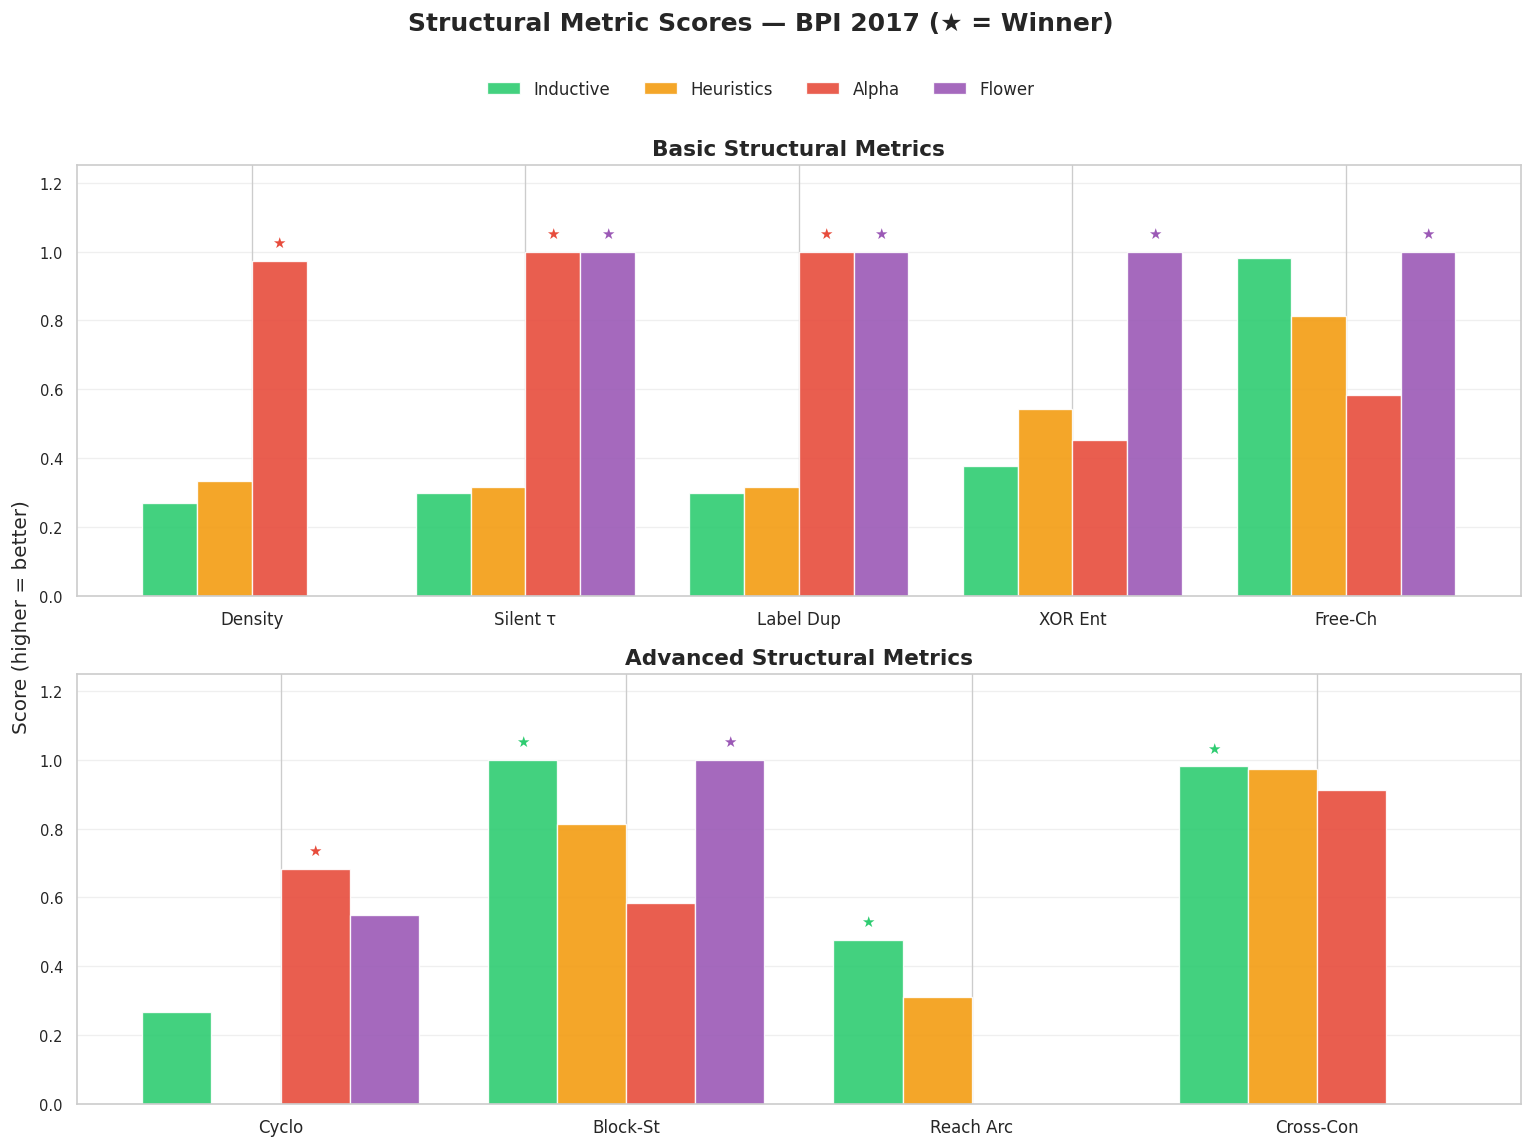

Who wins each metric?
  Density     : Alpha
  Silent τ    : Alpha, Flower
  Label Dup   : Alpha, Flower
  XOR Ent     : Flower
  Free-Ch     : Flower
  Cyclo       : Alpha
  Block-St    : Inductive, Flower
  Reach Arc   : Inductive
  Cross-Con   : Inductive

Win count: {'Inductive': 3, 'Heuristics': 0, 'Alpha': 4, 'Flower': 5}
Alpha + Flower combined wins: 9 / 9


In [4]:
# ── Raw metric values from analyze_struct_metrics.py (BPI 2017) ──
# IM: 55P/87T/184A  |  HM: 43P/82T/183A  |  AM: 12P/26T/55A  |  FM: 1P/26T/52A

# ── Score formulas (higher = better), per StructMetricAnalysis.md §1 ──
# Density:      exp(-(d-0.2)^2 / 0.02)   — Gaussian, best at 0.2
# Silent τ:     1 - silent_ratio           — fewer τ = better
# Label Dup:    1 / label_dup              — dup=1 = perfect
# XOR Entropy:  min(entropy / 3.0, 1)     — capped linear
# Free-Choice:  raw ratio                  — already [0,1]
# Cyclomatic:   1 - cyclo/max(cyclo)       — max=60 (Heuristics)
# Block-Struct: raw ratio                  — already [0,1]
# Reach Arc:    1 - reach_ratio            — lower reach = more headroom
# Cross-Conn:   1 - cross_conn             — lower = less spaghetti

metrics_basic  = ['Density', 'Silent τ', 'Label Dup', 'XOR Ent', 'Free-Ch']
metrics_adv    = ['Cyclo', 'Block-St', 'Reach Arc', 'Cross-Con']
all_metrics    = metrics_basic + metrics_adv

# Scores: [Inductive, Heuristics, Alpha, Flower]
scores = {
    'Density':    [0.271, 0.334, 0.972, 0.000],  # Gaussian(0.2)
    'Silent τ':   [0.299, 0.317, 1.000, 1.000],  # 1 - ratio
    'Label Dup':  [0.299, 0.317, 1.000, 1.000],  # 1/dup
    'XOR Ent':    [0.377, 0.543, 0.453, 1.000],  # min(ent/3,1)
    'Free-Ch':    [0.982, 0.814, 0.583, 1.000],  # raw
    'Cyclo':      [0.267, 0.000, 0.683, 0.550],  # 1-cyclo/60
    'Block-St':   [1.000, 0.814, 0.583, 1.000],  # raw
    'Reach Arc':  [0.478, 0.311, 0.000, 0.000],  # 1-reach
    'Cross-Con':  [0.981, 0.974, 0.912, 0.000],  # 1-crossconn
}

miner_colors = {'Inductive': '#2ECC71', 'Heuristics': '#F39C12',
                'Alpha': '#E74C3C', 'Flower': '#9B59B6'}
miner_order = ['Inductive', 'Heuristics', 'Alpha', 'Flower']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), sharey=True)

for ax, metrics, title in [
    (ax1, metrics_basic, 'Basic Structural Metrics'),
    (ax2, metrics_adv, 'Advanced Structural Metrics'),
]:
    x = np.arange(len(metrics))
    w = 0.2
    offsets = [-1.5*w, -0.5*w, 0.5*w, 1.5*w]
    
    for i, miner in enumerate(miner_order):
        vals = [scores[m][i] for m in metrics]
        bars = ax.bar(x + offsets[i], vals, w, label=miner,
                      color=miner_colors[miner], edgecolor='white', alpha=0.9)
        # Annotate winner bars with ★
        for j, (m, v) in enumerate(zip(metrics, vals)):
            all_vals = [scores[m][k] for k in range(4)]
            if v == max(all_vals) and v > 0:
                ax.text(x[j] + offsets[i], v + 0.04, '★', ha='center',
                        fontsize=9, color=miner_colors[miner], fontweight='bold')
    
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=10)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.25)
    ax.grid(True, alpha=0.3, axis='y')

# Single legend on top
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, 1.01), frameon=False)

fig.suptitle('Structural Metric Scores — BPI 2017 (★ = Winner)',
             fontsize=15, fontweight='bold', y=1.06)
fig.supylabel('Score (higher = better)', fontsize=12, x=0.02)
plt.tight_layout()
plt.show()

# ── Count wins per miner ──
print("Who wins each metric?")
for m in all_metrics:
    vals = scores[m]
    winners = [miner_order[i] for i, v in enumerate(vals) if v == max(vals)]
    print(f"  {m:12s}: {', '.join(winners)}")
print()
win_count = {miner: sum(1 for m in all_metrics
                        if scores[m][i] == max(scores[m]) and max(scores[m]) > 0)
             for i, miner in enumerate(miner_order)}
print("Win count:", win_count)
print(f"Alpha + Flower combined wins: {win_count['Alpha'] + win_count['Flower']} / {len(all_metrics)}")

- Alpha wins 4/9, Flower wins 5/9, Heuristics wins **0** — together Alpha+Flower win **all 9 metrics**, yet both are the worst models (Gen_Total = 0.66 & 0.53)
- Inductive wins 3/9 (Block-St, Reach Arc, Cross-Con) — the only realistic miner with wins
- **Underfitting blind spot**: Simplicity (few places, no silent τ, dup=1, 100% reach) earns top scores → pure structural metrics reward underfitting

## Slide 2.5: From 11 Metrics to 3 Dimensions — Selection Logic
**How did we pick ArcFlow, Reach, and Cyclo?** A three-round elimination based on discriminative power and complementary coverage (StructMetricAnalysis §6.1). **Gini was dropped**: it measures log-level transition frequency skew, not model structure — identical for Alpha/Flower across all datasets.

**Round 1 — Pure structural metrics (§1.1–§1.9):**

| Metric | § | Verdict | Reason |
|---|---|---|---|
| Reachable Arc Ratio | §1.8 | ✅ Promoted | IM 52% vs Alpha 100% — only anti-underfit guard |
| Cyclomatic Complexity | §1.6 | ✅ Promoted | V(G)=60 (Heuristics) vs 44 (IM) — detects spaghetti |
| Block-Structured Ratio | §1.7 | ⚠️ Omitted | IM always 100%; signal overlaps with Reach + Cyclo |
| Free-choice Ratio | §1.5 | ❌ Omitted | Redundant with Block-Structured |
| Cross-Connectivity | §1.9 | ❌ Eliminated | Anomalous on small graphs; needs calibration |
| Density | §1.1 | ❌ Eliminated | Calibration-dependent; IM ≈ Heuristics |
| Silent τ Ratio | §1.2 | ❌ Eliminated | IM 70% ≈ Heuristics 68% — non-discriminative |
| Label Duplication | §1.3 | ❌ Eliminated | Rewards underfitting (Alpha/Flower = 1.00×) |
| XOR-split Entropy | §1.4 | ❌ Eliminated | Narrow 1.13–1.63 range — no signal |

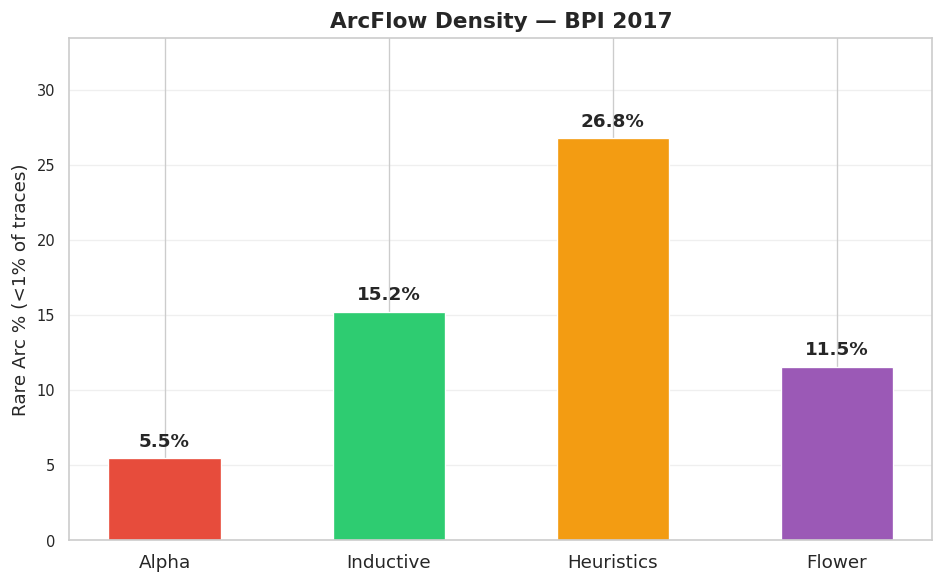

Rare arc %: {'Alpha': '5.5%', 'Inductive': '15.2%', 'Heuristics': '26.8%', 'Flower': '11.5%'}
ArcFlow: Heuristics has 1.8x more rare arcs than Inductive → strongest anti-overfit signal
Note: Gini dropped — Struct_gini_score = 0 for all 4 miners on BPI 2017 (non-discriminative)


In [5]:
# ── Replay-based metric: ArcFlow (Gini removed — see Slide 3) ──
# Token Variance (§4.3) omitted — 0% AND-split places on BPI 2017 for all miners
# Note: Gini removed from dimensions — Struct_gini_score = 0 for all models (non-discriminative)
import numpy as np

N_plot = '6'
replay_miners = ['02_Alpha Miner', '06_Inductive (Strict)', '04_Heuristics (Default)', '09_Flower Model (Max)']
replay_labels = ['Alpha', 'Inductive', 'Heuristics', 'Flower']

rare_arcs, total_arcs = [], []
for m in replay_miners:
    row = df_2017[df_2017['Miner'] == m].iloc[0]
    rare_arcs.append(row[f'v2.2_N={N_plot}_Raw_rare_arcs'])
    total_arcs.append(row[f'v2.2_N={N_plot}_Raw_total_arcs'])

rare_pct = [100*r/t for r, t in zip(rare_arcs, total_arcs)]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(replay_labels))
w = 0.5
colors = ['#E74C3C', '#2ECC71', '#F39C12', '#9B59B6']

bars = ax.bar(x, rare_pct, w, color=colors, edgecolor='white')
for i, pct in enumerate(rare_pct):
    ax.text(i, bars[i].get_height() + 0.8, f'{pct:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(replay_labels, fontsize=11)
ax.set_ylabel('Rare Arc % (<1% of traces)', fontsize=11)
ax.set_title('ArcFlow Density — BPI 2017', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(rare_pct)*1.25)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f'Rare arc %: {dict(zip(replay_labels, [f"{p:.1f}%" for p in rare_pct]))}')
print(f'ArcFlow: Heuristics has {rare_pct[2]/rare_pct[1]:.1f}x more rare arcs than Inductive → strongest anti-overfit signal')
print(f'Note: Gini dropped — Struct_gini_score = 0 for all 4 miners on BPI 2017 (non-discriminative)')


**Round 2 — The structural blind spot: cannot detect path overfitting**
A model with 1000 arcs each used once looks structurally fine but is pure memorization. To catch this we must **replay the log against the model** to measure actual arc usage.

| Metric | § | Verdict | Reason |
|---|---|---|---|
| ArcFlow Density | §4.1 | ✅ Promoted | Heuristics 25% rare arcs vs IM 15% — strongest anti-overfit |
| Transition Gini | §4.2 | ❌ Eliminated | non-discriminative |
| Token Variance | §4.3 | ❌ Eliminated | 0% AND-split places on BPI 2017 |

**Result: 4 dimensions = 1 replay + 2 structural**
Replay catches overfit / path bloat; structural catches underfit / trivial topology. The negative correlation between the two pairs (Slide 9) ensures no single threat dominates.

## Slide 3: Gen_Struct — Updated Formula (Gini removed, equal weights)
$$GenStruct = \frac{ArcFlow + (1 - Reach) + (1 - \frac{Cyclo}{\max(Cyclo)})}{3}$$

| Dimension | Weight | Type | What It Measures |
|---|---|---|---|
| **ArcFlow** | 1/3 | Replay | Rare arc ratio — penalizes bloated paths (anti-overfit) |
| **Reach** | 1/3 | Structural | Reachable arc ratio — penalizes trivial structure (anti-underfit) |
| **Cyclo** | 1/3 | Structural | Normalized cyclomatic complexity — penalizes spaghetti (anti-spaghetti) |

> **Gini removed**: It measured log-level transition frequency skew, not model structure. Across all 5 datasets, Alpha Miner and Flower Model always have identical Gini (both map activities 1:1 to transitions) — zero discriminative power.  
> Equal weights (1/3 each) — maximally defensible, no calibration assumption. Three dimensions map to three failure modes: overfit (ArcFlow), underfit (Reach), spaghetti (Cyclo).

## Slide 4: Gen_Struct v1 vs Updated Gen_Struct — Score Comparison
Updated Gen_Struct (Gini removed, equal weights) is more conservative across the board, penalizing all miners through multi-dimensional evaluation.

Key observation: Inductive overtakes Flower for #2. Alpha barely edges ahead of Inductive (0.543 vs 0.531) because its small model size (12P/26T) inflates ArcFlow and Cyclo scores despite zero reachability. Heuristics drops to last, correctly exposing its path-specific spaghetti structure.

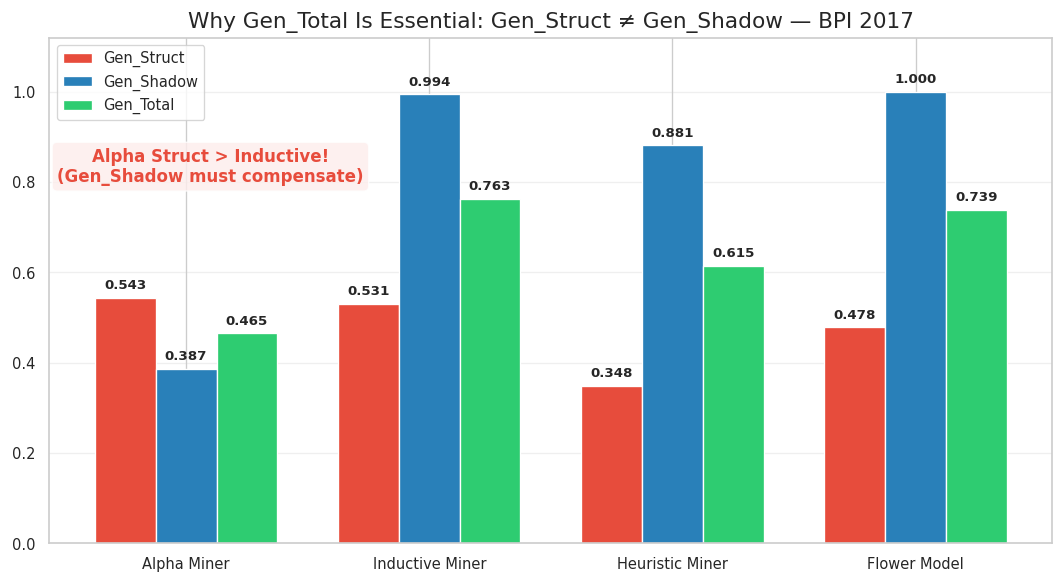

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
# Use BPI 2017 only — consistent with benchmark_analysis Cell 8 and Slides 1-2
df17 = df[df['Dataset'] == 'BPI_2017']
miner_order = ['02_Alpha Miner', '06_Inductive (Strict)', '04_Heuristics (Default)', '09_Flower Model (Max)']
miners_data = df17.groupby('Miner')[['v2.2_N=6_Gen_Struct', 'v2.2_N=6_Gen_Shadow', 'v2.2_N=6_Gen_Total']].mean()
miners_data = miners_data.reindex([m for m in miner_order if m in miners_data.index])
miners_data.index = [miner_short(m) for m in miners_data.index]

x = np.arange(len(miners_data)); w = 0.25
ax.bar(x - w, miners_data['v2.2_N=6_Gen_Struct'], w, label='Gen_Struct', color='#E74C3C', edgecolor='white')
ax.bar(x, miners_data['v2.2_N=6_Gen_Shadow'], w, label='Gen_Shadow', color='#2980B9', edgecolor='white')
ax.bar(x + w, miners_data['v2.2_N=6_Gen_Total'], w, label='Gen_Total', color='#2ECC71', edgecolor='white')
for i, (idx, row) in enumerate(miners_data.iterrows()):
    for j, col in enumerate(['v2.2_N=6_Gen_Struct', 'v2.2_N=6_Gen_Shadow', 'v2.2_N=6_Gen_Total']):
        ax.text(i + (j-1)*w, row[col]+0.02, f'{row[col]:.3f}', ha='center', fontsize=8, fontweight='bold')

ax.text(0.1, 0.8, 'Alpha Struct > Inductive!\n(Gen_Shadow must compensate)',
        ha='center', fontsize=10, color='#E74C3C', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#FDEDEC', alpha=0.8))

ax.set_xticks(x); ax.set_xticklabels(miners_data.index)
ax.set_title('Why Gen_Total Is Essential: Gen_Struct ≠ Gen_Shadow — BPI 2017', fontsize=13)
ax.legend(); ax.set_ylim(0, 1.12); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

- Alpha's Gen_Struct (0.543) > Inductive (0.531) — structure alone cannot distinguish good from bad  
- Gen_Shadow compensates: Alpha=0.387 vs Inductive=0.994 — log-based replay exposes Alpha's inability to generalize



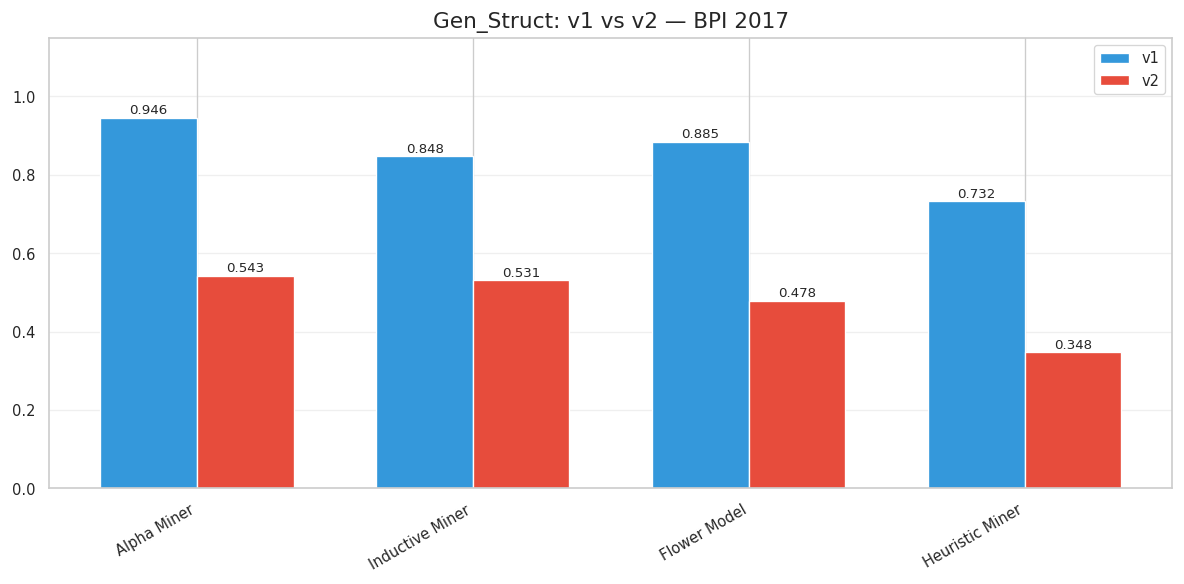

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
struct_rank = df_2017.groupby('Miner')[['v1_Gen_Struct', 'v2.2_N=6_Gen_Struct']].mean()
struct_rank.index = [miner_short(m) for m in struct_rank.index]
struct_rank = struct_rank.sort_values('v2.2_N=6_Gen_Struct', ascending=False)

x = np.arange(len(struct_rank)); w = 0.35
ax.bar(x - w/2, struct_rank['v1_Gen_Struct'], w, label='v1', color='#3498DB', edgecolor='white')
ax.bar(x + w/2, struct_rank['v2.2_N=6_Gen_Struct'], w, label='v2', color='#E74C3C', edgecolor='white')
for i, (idx, row) in enumerate(struct_rank.iterrows()):
    ax.text(i-w/2, row['v1_Gen_Struct']+0.01, f"{row['v1_Gen_Struct']:.3f}", ha='center', fontsize=8)
    ax.text(i+w/2, row['v2.2_N=6_Gen_Struct']+0.01, f"{row['v2.2_N=6_Gen_Struct']:.3f}", ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(struct_rank.index, rotation=30, ha='right')
ax.set_title('Gen_Struct: v1 vs v2 — BPI 2017', fontsize=13)
ax.set_ylim(0, 1.15); ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()


- Updated Gen_Struct penalizes ALL miners vs v1 — multi-dimensional evaluation is systematically more conservative
- **Heuristics, Flower, Alpha all drop ~0.39–0.41** (0.732→0.348, 0.885→0.478, 0.946→0.543) — each has a fatal structural flaw
- **Heuristics** — Reach (68.9%) + Cyclo (V(G)=60) both fire; only Heuristics has cyclo=0
- **Flower** — Reach=0 (100% reachable, single-place topology) + moderate Cyclo penalty
- **Alpha** — Reach=0 (100% reachable, no latent structure) but small model (12P/26T) inflates ArcFlow
- **Inductive drops least** (0.85→0.53, Δ=−0.32) — balanced across all three dimensions, no single weak flank


## Slide 5: Who Did Gen_Struct Penalize Most?
Δ = updated − v1. All miners are penalized — multi-dimensional evaluation is systematically more conservative.

**Final Gen_Struct ranking (BPI 2017):** Alpha (0.543) > Inductive (0.531) > Flower (0.478) > **Heuristics (0.348) ← worst!**

Δ order: Flower (−0.406) > Alpha (−0.403) > Heuristics (−0.384) > Inductive (−0.317). Flower drops the most because v1 inflated it (0 rare arcs → 0.968), but **Heuristics ends up lowest (0.348)** — the only miner below 0.35. Each non-Inductive miner has a fatal structural flaw (Heuristics: Cyclo=0 from V(G)≥60; Flower: Reach=0 from single-place topology; Alpha: Reach=0 from 100% reachability). Inductive alone resists because its profile is balanced across all three dimensions.



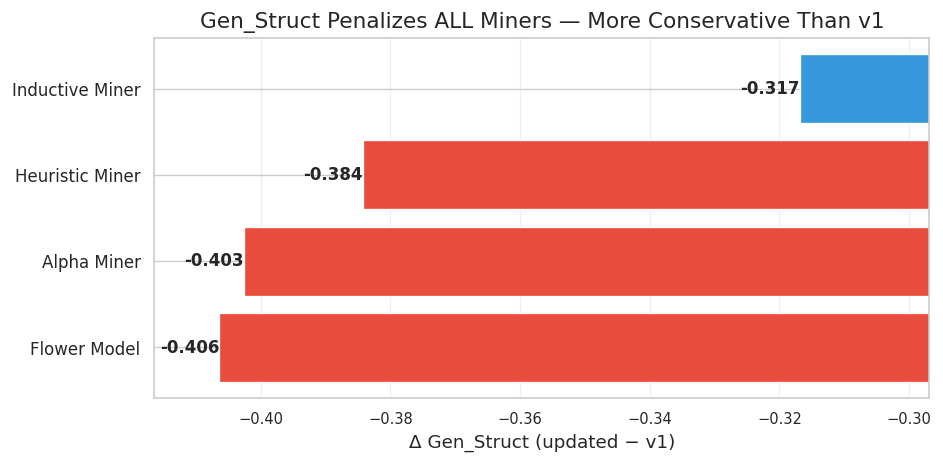

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
delta = (struct_rank['v2.2_N=6_Gen_Struct'] - struct_rank['v1_Gen_Struct']).sort_values()
colors = ['#E74C3C' if v < -0.38 else '#3498DB' for v in delta.values] 
ax.barh(range(len(delta)), delta.values, color=colors, edgecolor='white')
ax.set_yticks(range(len(delta)))
ax.set_yticklabels(delta.index, fontsize=10)
ax.set_xlabel('Δ Gen_Struct (updated − v1)'); ax.axvline(x=0, color='black', linewidth=1)
ax.set_title('Gen_Struct Penalizes ALL Miners — More Conservative Than v1', fontsize=13)
for i, v in enumerate(delta.values):
    ax.text(v, i, f'{v:+.3f}', va='center', ha='right', fontweight='bold', fontsize=10)
ax.grid(True, alpha=0.3, axis='x')
ax.set_xlim(delta.min() - 0.01, delta.max() + 0.02)
plt.tight_layout(); plt.show()


- Flower drops most in Δ (−0.406): v1 gave it 0.968 (0 rare arcs), v2's Reach=0 exposes the trivial structure — but Flower's final Gen_Struct (0.478) is still mid-pack
- **Heuristics ends up worst (0.348)**: lowest absolute Gen_Struct — Cyclo=0 (V(G)≥60) + Reach=0.319 both fire; starting from a lower v1 baseline (0.732), the multi-dimensional penalty pushes it to the bottom
- Penalty is not uniform — it reflects structural differences that v1's single dimension could not capture


## Slide 6: ⭐ Gen_Struct Alone Cannot Distinguish Alpha from Inductive
**This is the most important slide.** Even with 4 dimensions, Alpha Miner's Gen_Struct (0.543) is **higher** than Inductive Miner (0.531).

| Miner | Gen_Struct | Gen_Shadow | Gen_Total |
|---|---|---|---|
| Alpha Miner | **0.543** ← higher! | 0.387 | 0.465 |
| Inductive Miner | 0.531 | **0.994** | **0.763** |

Alpha's structural simplicity fools Gen_Struct. The defense against Alpha **must** come from Gen_Shadow, which correctly exposes its inability to replay future behavior. This is why Gen_Total = 0.5×Struct + 0.5×Shadow is essential.




## Slide 7: Gen_Struct vs Gen_Shadow — Two Complementary Perspectives
- **Above diagonal**: Shadow > Struct → model generalizes better than its structure suggests
- **Below diagonal**: Struct > Shadow → model's simplicity masks poor generalization (Alpha on 3/5 datasets)
- **Flower Model**: Shadow = 1.000 on ALL datasets (vertical line at top) — allows everything; Struct varies 0.22–0.55 depending on dataset


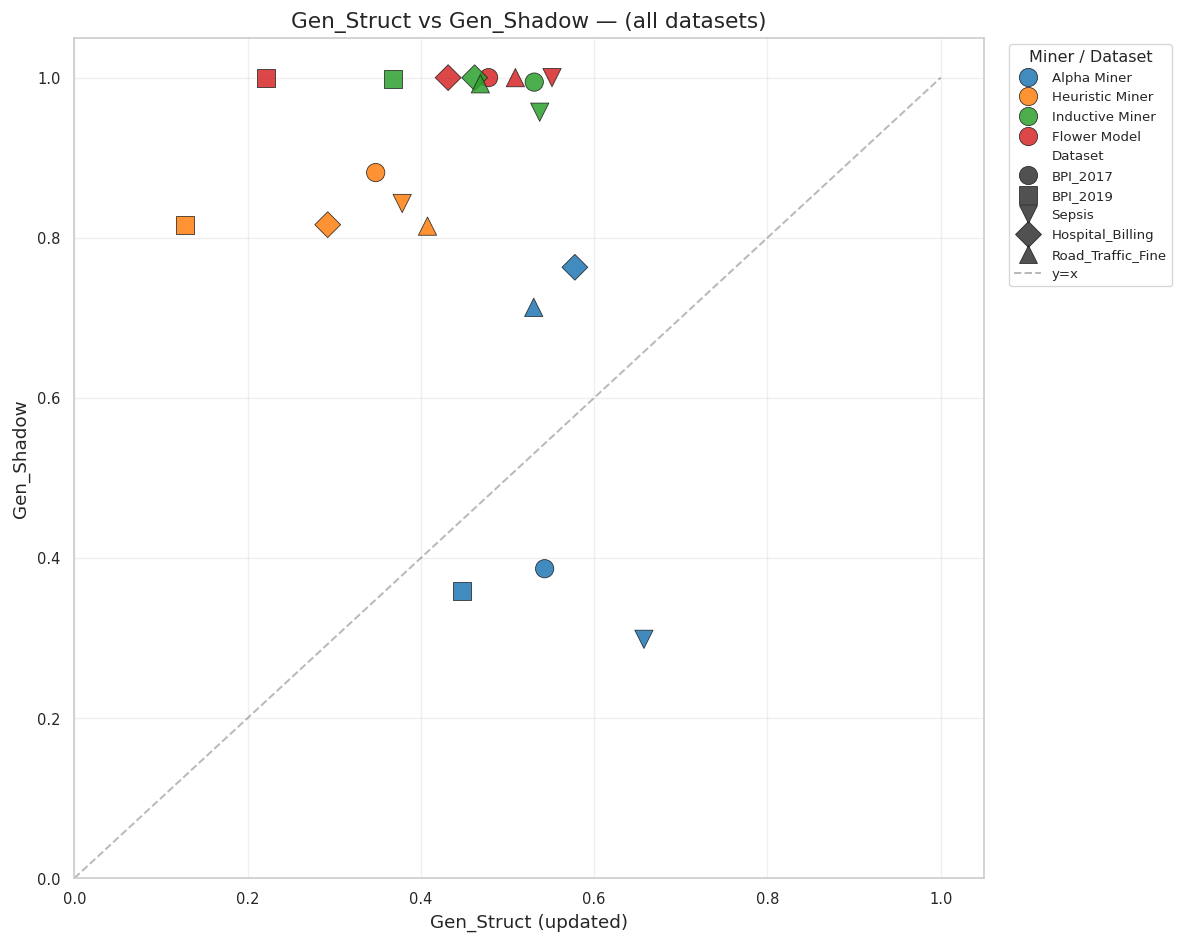

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
markers = ['o', 's', 'D', '^', 'v']
datasets = sorted(df['Dataset'].unique())
marker_map = {ds: m for ds, m in zip(datasets, markers)}

df['_ms'] = df['Miner'].apply(miner_short)
sns.scatterplot(data=df, x='v2.2_N=6_Gen_Struct', y='v2.2_N=6_Gen_Shadow',
                hue='_ms', style='Dataset', s=120, alpha=0.85, edgecolor='k', linewidth=0.5,
                palette='tab10', markers=marker_map, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='y=x')
ax.set_xlabel('Gen_Struct (updated)'); ax.set_ylabel('Gen_Shadow')
ax.set_title('Gen_Struct vs Gen_Shadow — (all datasets)', fontsize=13)
ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, title='Miner / Dataset')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


- Flower: Shadow = 1.000 on ALL 5 datasets (vertical line at top of plot) — the model accepts every trace; Struct varies 0.22–0.55 depending on how much the dataset exposes its trivial single-place topology  
- Alpha: splits across the diagonal — below on BPI_2017/2019/Sepsis (Shadow ≪ Struct, poor generalization), but above on Hospital_Billing/Road_Traffic_Fine (Shadow > Struct, decent replay fitness on simpler logs)
- Inductive: consistently high Shadow (~0.99) with moderate Struct — the only miner that dominates on both axes


## Slide 8: Gen_Struct — Per-Dimension Scores
Each miner has a distinct dimension profile across the three remaining dimensions (Gini removed).

Key patterns:
- **Alpha/Alpha+**: High Cyclo (simple structure), Reach=0 (100% reachable → trivial paths)
- **Heuristics**: Cyclo=0 (V(G)≥60), highest ArcFlow penalty
- **Inductive**: Balanced across all three dimensions — best overall
- **Flower**: Reach=0 (single-place topology), moderate Cyclo
- **Flower**: Reach = 0 (fully accessible)

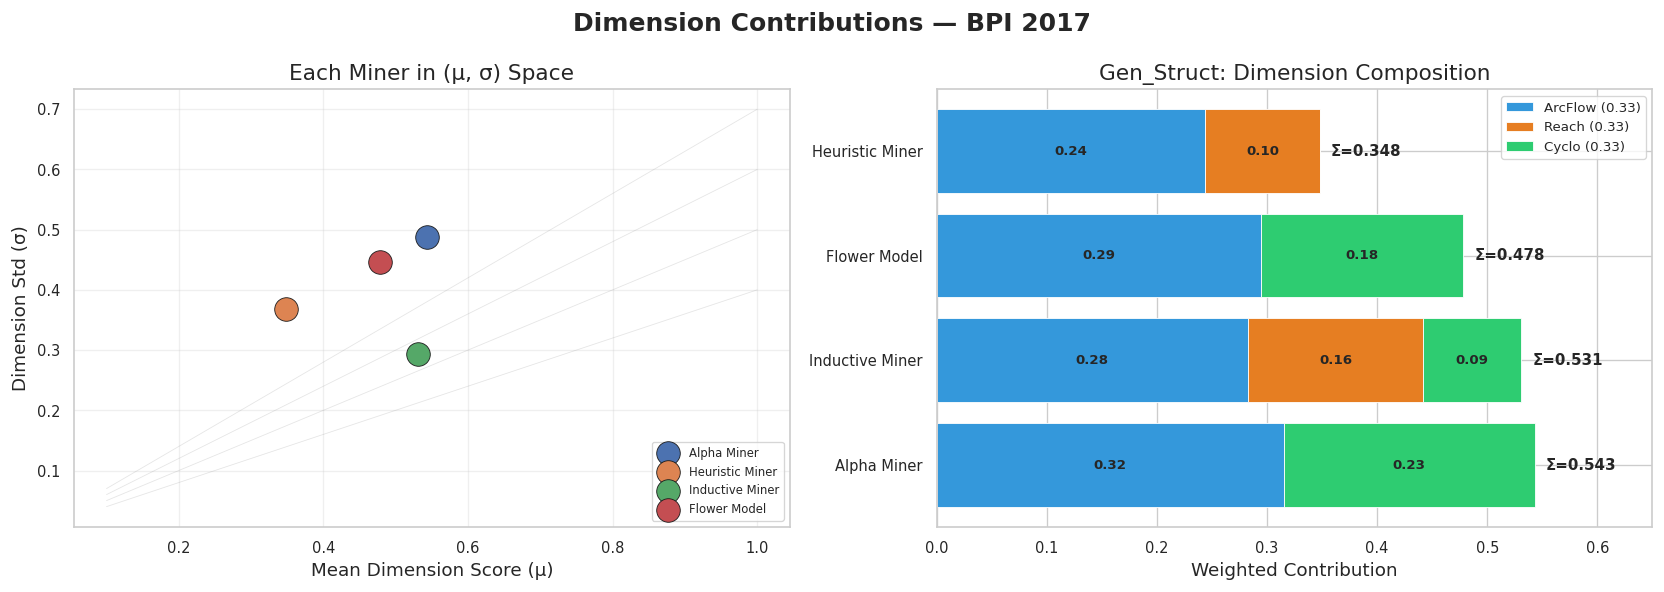

In [10]:
dim_std = dim_df.std(axis=1)
mean_dim = dim_df.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: μ vs σ space with CI contours
ax = axes[0]
for idx in dim_df.index:
    short = miner_short(idx)
    ax.scatter(mean_dim[idx], dim_std[idx], s=200, label=short[:15], edgecolors='k', linewidth=0.5)
ax.set_xlabel('Mean Dimension Score (μ)'); ax.set_ylabel('Dimension Std (σ)')
ax.set_title('Each Miner in (μ, σ) Space'); ax.legend(fontsize=7, loc='lower right')
for ci in [0.4, 0.5, 0.6, 0.7]:
    xs_line = np.linspace(0.1, 1, 100)
    ys_line = xs_line * ci
    ax.plot(xs_line, ys_line, 'gray', alpha=0.2, linewidth=0.5)
ax.grid(True, alpha=0.3)

# Right: Stacked bar — weighted contributions
ax = axes[1]
short_labels = ['ArcFlow', 'Reach', 'Cyclo']  # Gini removed
weighted_w = dim_df.copy()
for i, col in enumerate(dim_df.columns):
    weighted_w[f'{short_labels[i]}_w'] = dim_df[col] * CURRENT_W[i]
weighted_cols_w = [f'{s}_w' for s in short_labels]

# Sort by total score using original index, then rename
final_scores = weighted_w[weighted_cols_w].sum(axis=1).sort_values(ascending=False)
ordered_original = final_scores.index
ordered_short = [miner_short(m) for m in ordered_original]

bottom = np.zeros(len(ordered_short))
colors_dim = ['#3498DB', '#E67E22', '#2ECC71', '#E74C3C']
for i, col in enumerate(weighted_cols_w):
    vals = weighted_w.loc[ordered_original, col].values
    ax.barh(range(len(ordered_short)), vals, left=bottom, color=colors_dim[i],
            label=f'{short_labels[i]} ({CURRENT_W[i]:.2f})', edgecolor='white', linewidth=0.5)
    # Annotate each segment if significant (>0.01)
    for j, v in enumerate(vals):
        if v > 0.01:
            ax.text(bottom[j] + v/2, j, f'{v:.2f}', ha='center', va='center',
                    fontsize=8, fontweight='bold')
    bottom += vals
ax.set_yticks(range(len(ordered_short)))
ax.set_yticklabels(ordered_short)
ax.set_xlabel('Weighted Contribution'); ax.set_title('Gen_Struct: Dimension Composition')
ax.legend(loc='upper right', fontsize=8); ax.set_xlim(0, 0.65)
# Add total score label
for j, idx in enumerate(ordered_original):
    ax.text(weighted_w.loc[idx, weighted_cols_w].sum() + 0.01, j,
            f'Σ={final_scores[idx]:.3f}', va='center', fontsize=9, fontweight='bold')

fig.suptitle('Dimension Contributions — BPI 2017', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

- **Left (μ-σ space)**: Flower at moderate-μ high-σ (μ=0.478, σ=0.447, CI=0.934) — well above CI=0.7 contour; Inductive at balanced position (μ=0.531, σ=0.294, CI=0.554); Heuristics has highest CI=1.056  
- **Right (composition)**: ArcFlow dominates contributions; Reach barely contributes for Flower (0.00) — catches the trivial model


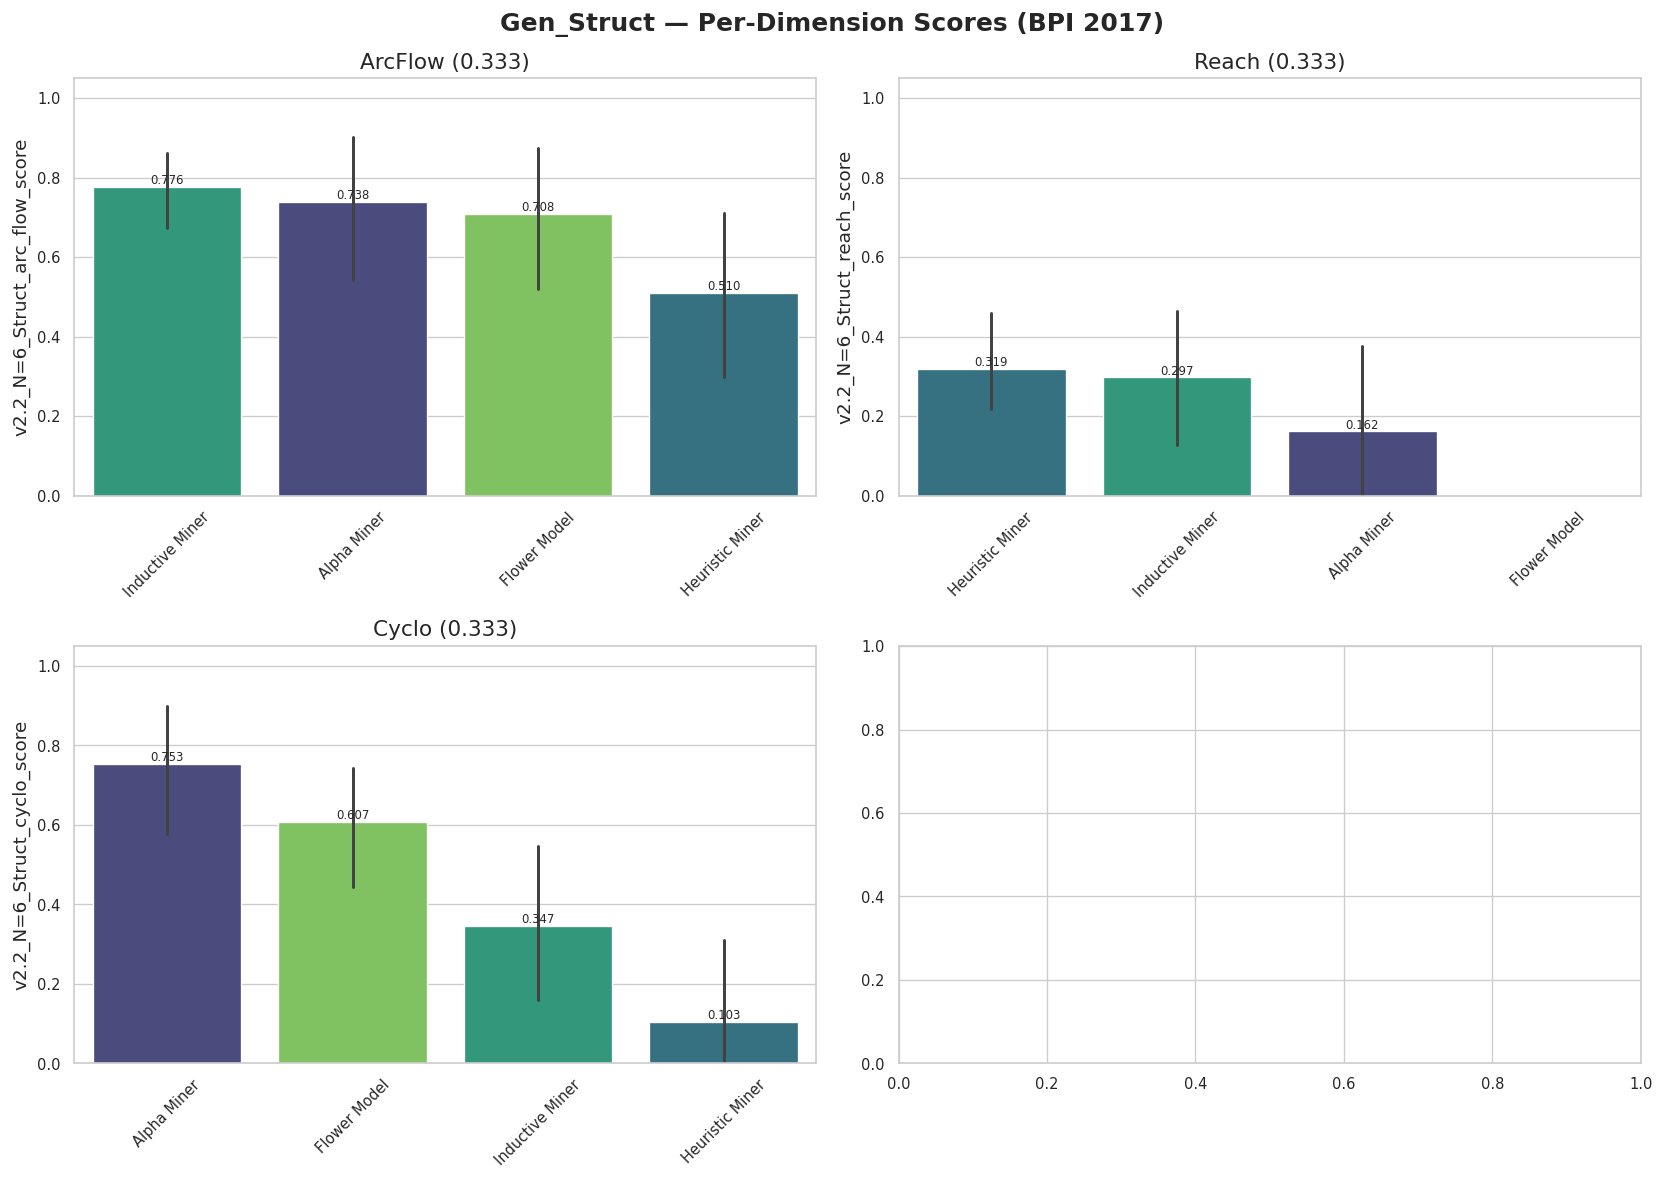

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
dim_label_full = ['ArcFlow (0.333)', 'Reach (0.333)', 'Cyclo (0.333)']  # equal weights

for i, (dim, label) in enumerate(zip(DIMS, dim_label_full)):
    ax = axes[i//2, i%2]
    col = f'v2.2_N=6_Struct_{dim}'
    order = df.groupby('Miner')[col].mean().sort_values(ascending=False)
    order.index = [miner_short(m) for m in order.index]
    # Use hue to avoid palette warning, set legend=False
    sns.barplot(data=df.assign(Miner_Label=df['Miner'].apply(miner_short)), x='Miner_Label', y=col,
                hue='Miner_Label', order=order.index, palette='viridis', legend=False, ax=ax)
    ax.set_title(f'{label}'); ax.set_ylim(0, 1.05)
    ax.set_xlabel(''); ax.tick_params(axis='x', rotation=45)
    for p in ax.patches:
        h = p.get_height()
        if h > 0.01:
            ax.annotate(f'{h:.3f}', (p.get_x()+p.get_width()/2., h), ha='center', va='bottom', fontsize=7)

fig.suptitle('Gen_Struct — Per-Dimension Scores (BPI 2017)', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()


- ArcFlow: Inductive & Alpha high (few rare arcs), Heuristic low (26.8% bloated paths, highest rare arc ratio) — penalizes overfitting  
- Reach: Flower=0.000 vs Inductive=0.297 — uniquely detects the fully-accessible trivial model that ArcFlow misses


## Slide 9: Dimension Inter-Correlation Matrix (Gini removed)
Gini was removed: r = +0.93 with ArcFlow (both replay-based, strongly redundant), and identical for Alpha/Flower models across all datasets.

| Pair | Pearson r | Relationship |
|---|---|---|
| ArcFlow ↔ Reach | **−0.620** | Orthogonal guards |
| Reach ↔ Cyclo | **−0.776** | Reach penalizes simplicity, Cyclo penalizes complexity |
| ArcFlow ↔ Cyclo | **+0.975** | Strong positive — both penalize complexity (partially redundant) |

The two structural metrics (Reach, Cyclo) are negatively correlated with each other — one penalizes underfit, the other penalizes overfit/spaghetti. This is exactly what we want. Note: ArcFlow↔Cyclo r=+0.975 — both penalize model complexity; ArcFlow captures the replay-level rare-arc density while Cyclo captures the graph-level cyclomatic complexity.




In [12]:
dim_df.copy().rename(index=miner_short, columns={f'v2.2_N={N}_Struct_{d}': f'{l}' for i, (d, l) in enumerate(zip(DIMS, DIM_LABELS))})

,ArcFlow,Reach,Cyclo
Miner,,,
Alpha Miner,0.9455,0.0000,0.6833
Heuristic Miner,0.7322,0.3115,0.0000
Inductive Miner,0.8478,0.4783,0.2667
Flower Model,0.8846,0.0000,0.5500


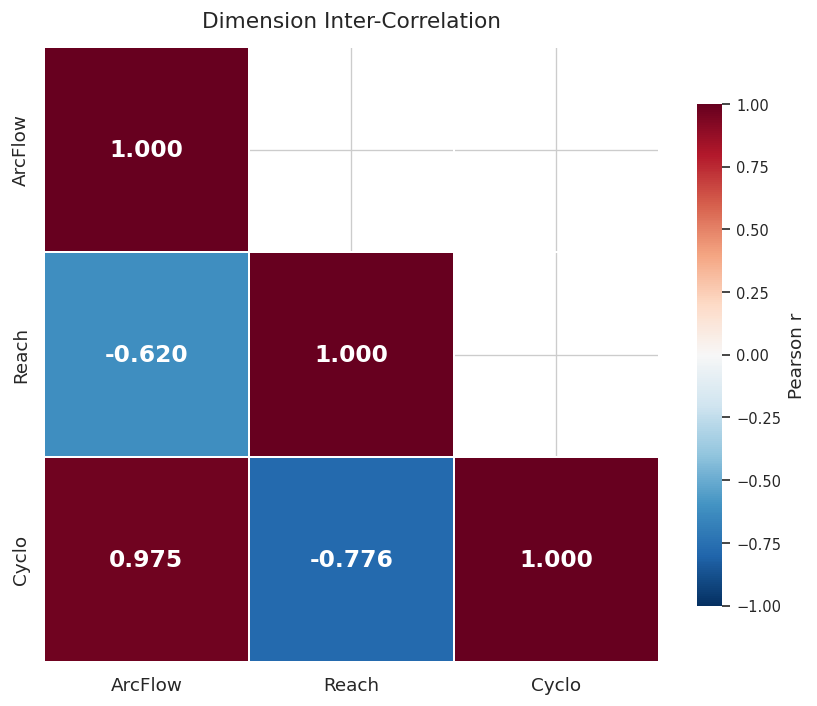

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
corr_matrix = dim_df.corr()
corr_matrix.index = DIM_LABELS; corr_matrix.columns = DIM_LABELS

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            vmin=-1, vmax=1, center=0, square=True, linewidths=1,
            cbar_kws={'shrink': 0.75, 'label': 'Pearson r'}, ax=ax,
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
ax.set_title('Dimension Inter-Correlation', fontsize=13, pad=12)
ax.tick_params(labelsize=11)
plt.tight_layout(); plt.show()


- Gini removed: r=+0.93 with ArcFlow (both replay-based, highly redundant) + always identical for Alpha/Flower models — confirmed non-discriminative  
- Reach ↔ Cyclo (r=−0.776) & Reach ↔ ArcFlow (r=−0.620): Reach guards the opposite flank — negatively correlated by design
- ArcFlow ↔ Cyclo (r=+0.975): Both penalize complexity — ArcFlow at replay level (rare arcs), Cyclo at graph level (V(G)). High but not identical — different mechanisms.



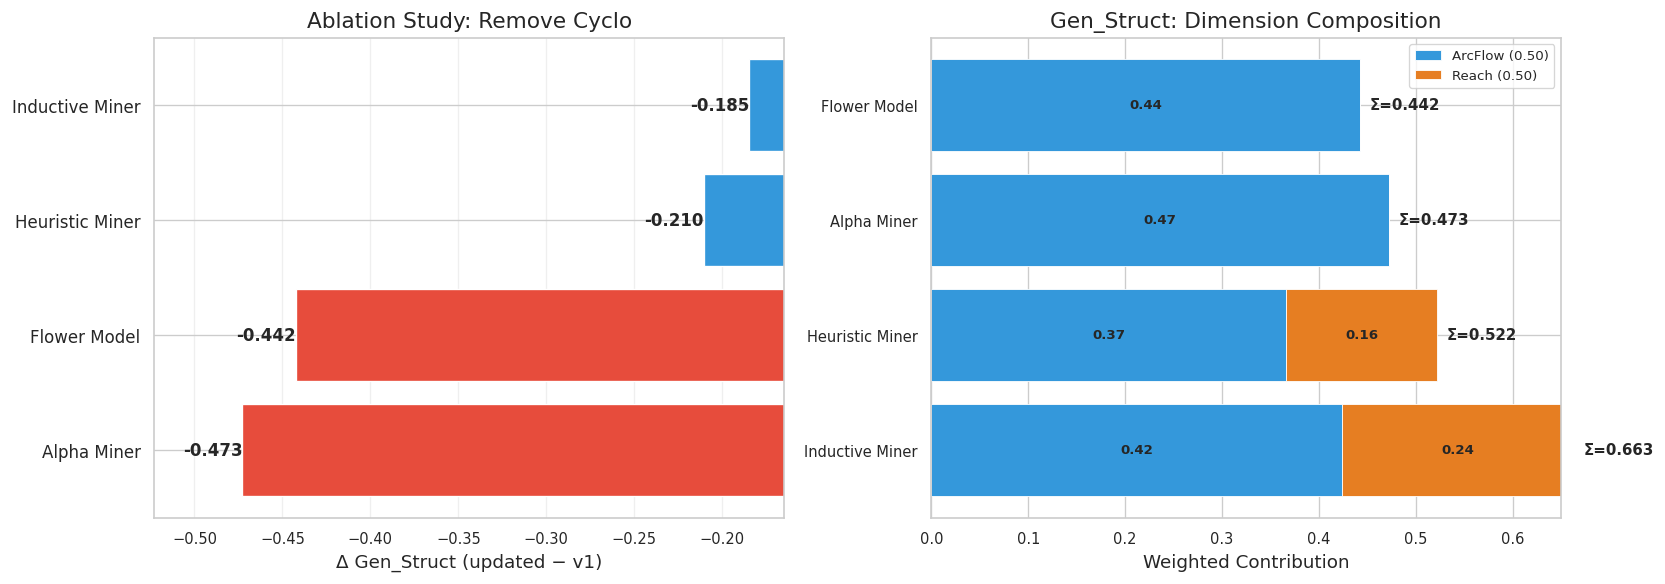

In [14]:
# ablation study: remove cyclo
CURRENT_W_ablate = [1/2, 1/2]  # equal weights
dim_df_ablate = dim_df.drop(columns=[f'v2.2_N=6_Struct_cyclo_score']).copy().rename(index=miner_short)
dim_std = dim_df_ablate.std(axis=1)
mean_dim = dim_df_ablate.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: who did we penalize the most by removing cyclo? (BPI 2017 only)
ax = axes[0]
delta = (mean_dim.loc[struct_rank.index] - struct_rank['v1_Gen_Struct']).sort_values()
colors = ['#E74C3C' if v < -0.38 else '#3498DB' for v in delta.values] 
ax.barh(range(len(delta)), delta.values, color=colors, edgecolor='white')
ax.set_yticks(range(len(delta)))
ax.set_yticklabels(delta.index, fontsize=10)
ax.set_xlabel('Δ Gen_Struct (updated − v1)'); ax.axvline(x=0, color='black', linewidth=1)
ax.set_title('Ablation Study: Remove Cyclo', fontsize=13)
for i, v in enumerate(delta.values):
    ax.text(v, i, f'{v:+.3f}', va='center', ha='right', fontweight='bold', fontsize=10)
ax.grid(True, alpha=0.3, axis='x')
ax.set_xlim(delta.min() - 0.05, delta.max() + 0.02)

# Right: Stacked bar — weighted contributions
ax = axes[1]
short_labels = ['ArcFlow', 'Reach']  # Gini removed
weighted_w = dim_df_ablate.copy()
for i, col in enumerate(dim_df_ablate.columns):
    weighted_w[f'{short_labels[i]}_w'] = dim_df_ablate[col] * CURRENT_W_ablate[i]
weighted_cols_w = [f'{s}_w' for s in short_labels]

# Sort by total score using original index, then rename
final_scores = weighted_w[weighted_cols_w].sum(axis=1).sort_values(ascending=False)
ordered_original = final_scores.index
ordered_short = [miner_short(m) for m in ordered_original]

bottom = np.zeros(len(ordered_short))
colors_dim = ['#3498DB', '#E67E22', '#2ECC71', '#E74C3C']
for i, col in enumerate(weighted_cols_w):
    vals = weighted_w.loc[ordered_original, col].values
    ax.barh(range(len(ordered_short)), vals, left=bottom, color=colors_dim[i],
            label=f'{short_labels[i]} ({CURRENT_W_ablate[i]:.2f})', edgecolor='white', linewidth=0.5)
    # Annotate each segment if significant (>0.01)
    for j, v in enumerate(vals):
        if v > 0.01:
            ax.text(bottom[j] + v/2, j, f'{v:.2f}', ha='center', va='center',
                    fontsize=8, fontweight='bold')
    bottom += vals
ax.set_yticks(range(len(ordered_short)))
ax.set_yticklabels(ordered_short)
ax.set_xlabel('Weighted Contribution'); ax.set_title('Gen_Struct: Dimension Composition')
ax.legend(loc='upper right', fontsize=8); ax.set_xlim(0, 0.65)
# Add total score label
for j, idx in enumerate(ordered_original):
    ax.text(weighted_w.loc[idx, weighted_cols_w].sum() + 0.01, j,
            f'Σ={final_scores[idx]:.3f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout(); plt.show()

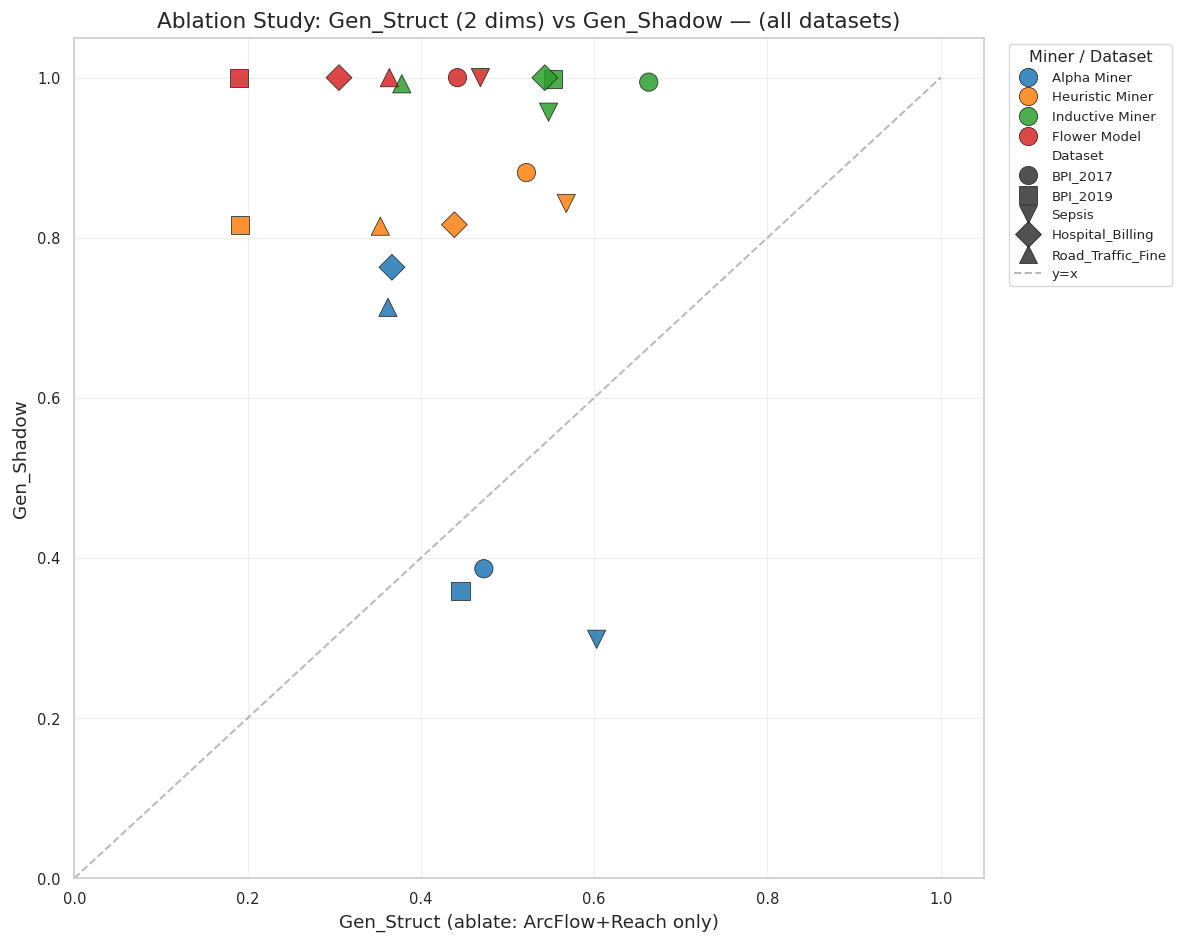

In [15]:
# ── Ablation Study: cross-dataset 2D scatter (remove Cyclo, only ArcFlow+Reach) ──
df['v2.2_N=6_Gen_Struct_ablate'] = 0.5 * df['v2.2_N=6_Struct_arc_flow_score'] + 0.5 * df['v2.2_N=6_Struct_reach_score']

fig, ax = plt.subplots(figsize=(10, 8))
markers = ['o', 's', 'D', '^', 'v']
datasets = sorted(df['Dataset'].unique())
marker_map = {ds: m for ds, m in zip(datasets, markers)}

df['_ms'] = df['Miner'].apply(miner_short)

sns.scatterplot(data=df, x='v2.2_N=6_Gen_Struct_ablate', y='v2.2_N=6_Gen_Shadow',
                hue='_ms', style='Dataset', s=120, alpha=0.85, edgecolor='k', linewidth=0.5,
                palette='tab10', markers=marker_map, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='y=x')
ax.set_xlabel('Gen_Struct (ablate: ArcFlow+Reach only)')
ax.set_ylabel('Gen_Shadow')
ax.set_title('Ablation Study: Gen_Struct (2 dims) vs Gen_Shadow — (all datasets)', fontsize=13)
ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, title='Miner / Dataset')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Slide 10: Multi-Dimensional Tension Analysis
**Cancellation Index (CI) = σ/μ** — measures how much dimensions disagree per miner.

| Miner | CI | Interpretation |
|---|---|---|
| Flower Model | **0.934** | Cyclo high (simple) — Reach zero (fully exposed) |
| Heuristic Miner | **1.056** | Highest tension — Cyclo=0 from V(G)≥60 vs Reach=0.319 |
| Alpha Miner | 0.899 | Same pattern, less extreme |
| Inductive (Strict) | **0.554** | All dimensions balanced — lowest conflict |

High CI is not a flaw — it is the **mathematical footprint of catching a fraudulent model**.





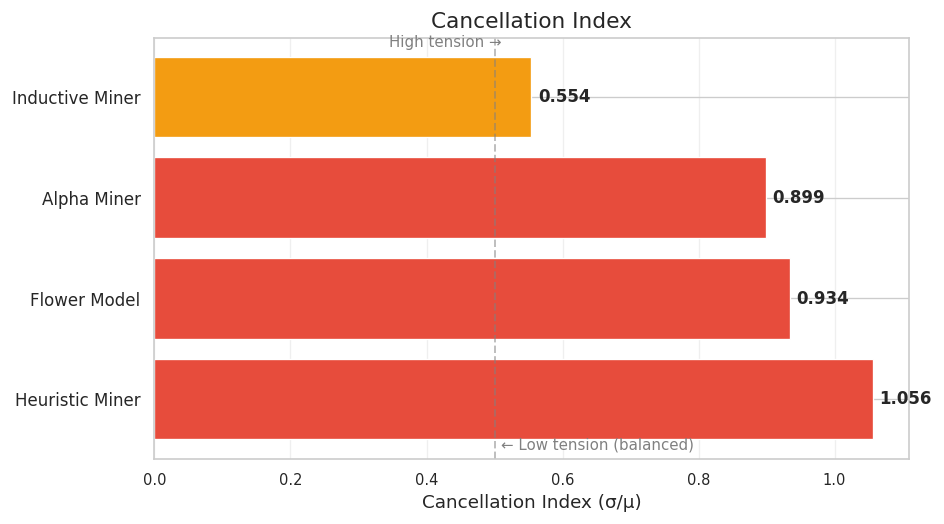

In [16]:
dim_std = dim_df.std(axis=1)
mean_dim = dim_df.mean(axis=1)
cancel_idx = (dim_std / mean_dim).sort_values(ascending=False)
cancel_idx.index = [miner_short(m) for m in cancel_idx.index]

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['#E74C3C' if v > 0.6 else '#F39C12' if v > 0.5 else '#2ECC71' for v in cancel_idx.values]
bars = ax.barh(range(len(cancel_idx)), cancel_idx.values, color=colors, edgecolor='white')
ax.set_yticks(range(len(cancel_idx))); ax.set_yticklabels(cancel_idx.index, fontsize=10)
ax.set_xlabel('Cancellation Index (σ/μ)'); ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Cancellation Index', fontsize=13)
for i, v in enumerate(cancel_idx.values):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontweight='bold', fontsize=10)
ax.text(0.51, -0.5, '← Low tension (balanced)', fontsize=9, color='gray')
ax.text(0.51, len(cancel_idx)-0.5, 'High tension →', fontsize=9, color='gray', ha='right')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout(); plt.show()


- Flower CI=0.934: dimensions violently disagree — Cyclo says "simple", Reach says "99% accessible = underfit"  
- Heuristics CI=1.056: highest tension — Cyclo=0 (V(G)≥60, spaghetti) vs Reach=0.319 (some unreachable arcs), maximal dimension conflict
- Alpha CI=0.899: high tension — ArcFlow=0.738/Cyclo=0.753 (simple model) vs Reach=0.162 (near-zero reachability penalty)
- Inductive CI=0.554: lowest tension → model is genuinely balanced, doesn't rely on extreme scores in any single dimension




## Slide 11: Cancellation = Feature, Not Bug
**The "conflict" between dimensions is an intentional defense mechanism.**

| Scenario | Dimensions | Result |
|---|---|---|
| Remove Reach | Flower score jumps from 0.478 → 0.658 | Flower escapes detection |
| Keep all 4 | Flower CI = 0.934 → caught | Metric flags the fraud |

The negative Reach↔Cyclo correlation (−0.776) is the system actively defending against models that try to cheat by being trivially simple or unnecessarily complex. **A genuinely good model (Inductive) has the lowest CI because it doesn't need extreme tradeoffs.**



## Slide 12: The Defense Matrix — Each Metric Guards a Different Threat
**Gen_Struct and Gen_Shadow each guard against what the other cannot detect.**

| Threat | Gen_Struct | Gen_Shadow | Gen_Total |
|---|---|---|---|
| **Flower Model** (allows everything) | ✅ Caught (Reach=0) | ❌ Fooled (score=1.0) | ✅ Caught |
| **Alpha Miner** (too simple) | ⚠️ Partial (Reach=0 penalized but small model inflates ArcFlow/Cyclo) | ✅ Caught (replay fails) | ✅ Caught |
| **Heuristic Miner** (overly complex) | ✅ Caught (Cyclo=0 + Reach penalty) | ✅ Fine | ⚠️ Borderline |
| **Inductive Miner** (genuinely good) | ✅ Balanced across all 3 dims | ✅ High shadow fitness | ✅ Best overall |

**Neither metric is sufficient alone.** Gen_Total = 0.5×Struct + 0.5×Shadow ensures that both failure modes are covered.